# 02 — JPEG Ghost

O JPEG Ghost recomprime a imagem em várias qualidades (50 a 90) e, para cada bloco de 16x16, anota em qual qualidade o erro de recompressão é mínimo. Uma região colada de outra fonte tende a "preferir" uma qualidade diferente da do resto do documento — esse é o fantasma. Aqui avaliamos se isso acontece nas regiões adulteradas do split `test` do *Find it again!*, usando a mesma metodologia região-vs-controle do notebook da ELA.

A explicação teórica (por que o erro tem um vale na qualidade original, escolhas de implementação, limitações) está em [`report/fundamentacao_jpeg_ghost.md`](../report/fundamentacao_jpeg_ghost.md).

In [1]:
import sys
sys.path.append("../src")

import random
from collections import Counter
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from dataset_loader import load_dataset, TamperRegion
from jpeg_ghost import (DEFAULT_QUALITIES, compute_jpeg_ghost, compute_region_ghost_score,
                        has_jpeg_history, visualize_jpeg_ghost)
from ela import compute_ela, compute_region_score

QS = DEFAULT_QUALITIES
print("qualidades testadas:", list(QS))

qualidades testadas: [50, 55, 60, 65, 70, 75, 80, 85, 90]


## 1. Carregando o split `test`

In [2]:
DATASET_ROOT = "../data/findit2"

samples = load_dataset(DATASET_ROOT, "test")
forged = [s for s in samples if s.is_tampered and s.regions]
n_tampered = sum(s.is_tampered for s in samples)
print(f"total: {len(samples)} | autênticos: {len(samples) - n_tampered} | adulterados: {n_tampered} "
      f"| adulterados com regiões anotadas: {len(forged)}")

total: 218 | autênticos: 183 | adulterados: 35 | adulterados com regiões anotadas: 35


## 2. Pré-requisito: as imagens têm histórico JPEG?

Todas as imagens do dataset são **PNG**. O JPEG Ghost não lê o formato do arquivo: ele procura nos pixels o *vestígio* de uma compressão JPEG anterior. Se uma imagem nunca passou por JPEG, a curva de erro × qualidade só decresce e a técnica fica cega.

Por isso, antes de qualquer análise, verificamos em cada imagem se a curva de erro da imagem inteira tem um **vale interno** (`has_jpeg_history`). A qualidade onde o vale aparece é uma estimativa da qualidade JPEG original.

In [3]:
history = {s.image_path.name: has_jpeg_history(s.image_path) for s in samples}

for name, group in (("autêntico", [s for s in samples if not s.is_tampered]),
                    ("adulterado", [s for s in samples if s.is_tampered])):
    n_hist = sum(history[s.image_path.name][0] for s in group)
    print(f"{name:<11} com histórico JPEG detectável: {n_hist}/{len(group)} ({n_hist / len(group):.0%})")

valleys = Counter(q for has, q in history.values() if has)
print("\nqualidade estimada do vale (todas as imagens):", dict(sorted(valleys.items())))

autêntico   com histórico JPEG detectável: 158/183 (86%)
adulterado  com histórico JPEG detectável: 30/35 (86%)

qualidade estimada do vale (todas as imagens): {55: 8, 60: 4, 70: 46, 75: 105, 80: 2, 85: 23}


**Decisão.** A maioria das imagens **tem** histórico JPEG detectável, com vale concentrado em q ≈ 75. Isso faz sentido: os recibos do *Find it again!* vêm do SROIE, que foi digitalizado e salvo em JPEG antes de ser convertido para PNG. A conversão para PNG não tem perda e preserva a "memória" da quantização. Portanto **não é preciso restringir a análise a um subconjunto**.

Ainda assim, adotamos duas salvaguardas:

1. **Validação sintética** (próxima seção): antes de olhar as adulterações reais, testamos a implementação num cenário controlado onde sabemos que o fantasma existe. Assim, separamos "a técnica não funciona" de "a técnica funciona, mas as adulterações deste dataset não deixam esse rastro".
2. **Estratificação** na avaliação real: reportamos o resultado separadamente para imagens com e sem histórico detectável.

## 3. Validação sintética

Pegamos 30 imagens autênticas (seed fixa) e substituímos um retângulo de 64x48 px, sorteado sobre uma área com texto, pela versão do mesmo trecho comprimida em JPEG qualidade 60. Isso simula um trecho colado de uma fonte com outra compressão. A imagem resultante é mantida sem perda, como no dataset.

- **Detecção:** com a colagem, a qualidade dominante dentro do retângulo difere da do resto da imagem?
- **Falso positivo:** sem colagem, no mesmo retângulo, as qualidades dominantes diferem?

In [4]:
def random_region(ghost_map, w, h, avoid=(), rng=random, block_size=16, max_tries=200):
    """Sorteia um retângulo w x h que não sobrepõe `avoid` e contém ao menos
    um bloco válido (com textura) no ghost_map. Retorna TamperRegion ou None."""
    H, W = ghost_map.shape[0] * block_size, ghost_map.shape[1] * block_size
    for _ in range(max_tries):
        x, y = rng.randint(0, max(0, W - w)), rng.randint(0, max(0, H - h))
        if any(not (x + w <= a.bbox[0] or x >= a.bbox[0] + a.bbox[2] or
                    y + h <= a.bbox[1] or y >= a.bbox[1] + a.bbox[3]) for a in avoid):
            continue
        r = TamperRegion(bbox=(x, y, w, h), modification="CONTROLE", entity_type=None, is_original_area=None)
        inside, _ = compute_region_ghost_score(ghost_map, [r], block_size)
        if inside is not None:
            return r
    return None


def jpeg_roundtrip(gray, quality):
    import io
    buf = io.BytesIO()
    Image.fromarray(gray).save(buf, "JPEG", quality=quality)
    buf.seek(0)
    return np.asarray(Image.open(buf))


def to_gray(path):
    img = Image.open(path)
    if img.mode in ("RGBA", "LA"):
        img = Image.alpha_composite(Image.new("RGBA", img.size, "white"), img.convert("RGBA"))
    return np.asarray(img.convert("L"))


rng = random.Random(0)
authentic = [s for s in samples if not s.is_tampered]
hits = false_pos = n = 0
for s in rng.sample(authentic, 30):
    gray = to_gray(s.image_path)
    ghost_clean = compute_jpeg_ghost(Image.fromarray(gray))
    r = random_region(ghost_clean, 64, 48, rng=rng)
    if r is None:
        continue
    x, y, w, h = r.bbox
    spliced = gray.copy()
    spliced[y:y + h, x:x + w] = jpeg_roundtrip(gray, 60)[y:y + h, x:x + w]
    ghost_spliced = compute_jpeg_ghost(Image.fromarray(spliced))

    a, b = compute_region_ghost_score(ghost_spliced, [r]); hits += a != b
    a, b = compute_region_ghost_score(ghost_clean, [r]);   false_pos += a != b
    n += 1

print(f"detecção:       {hits}/{n} ({hits / n:.0%})")
print(f"falso positivo: {false_pos}/{n} ({false_pos / n:.0%})")

detecção:       18/30 (60%)
falso positivo: 1/30 (3%)


A implementação funciona quando a premissa da técnica vale (trecho com compressão diferente da do documento): a detecção é alta e o falso positivo é baixo. Agora vamos às adulterações reais.

## 4. Inspeção visual

Mapas de três adulterados. Cada cor é a qualidade que minimizou o erro naquele bloco. Blocos lisos (papel em branco) ficam sem cor. Os retângulos vermelhos são as regiões anotadas.

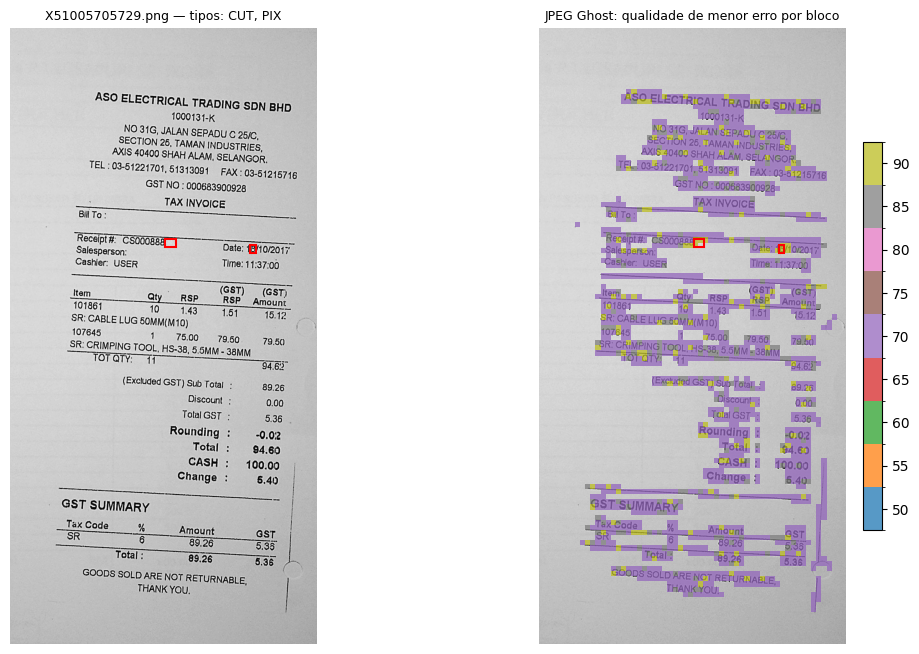

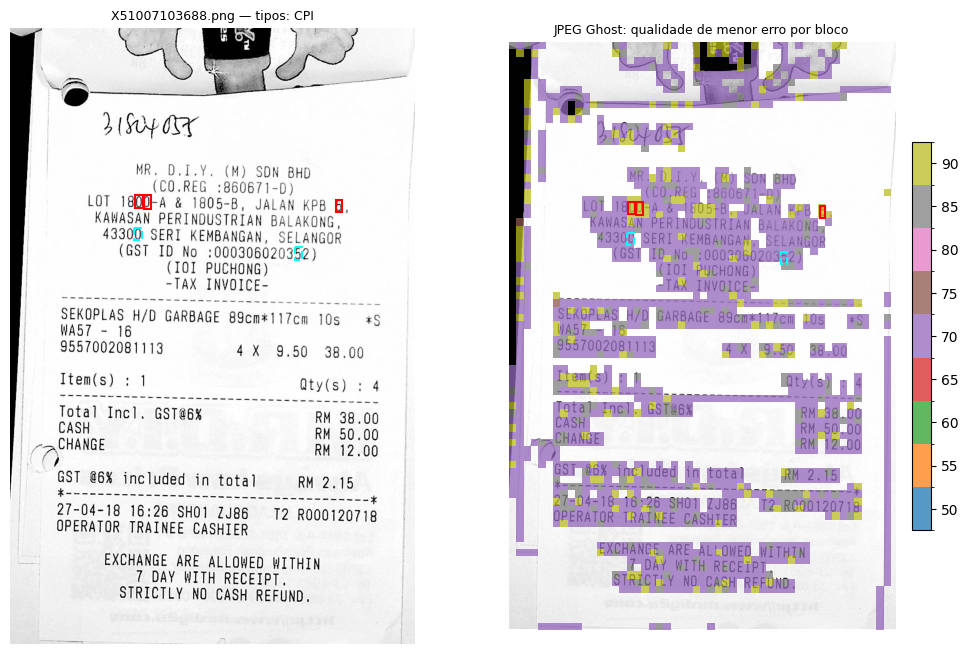

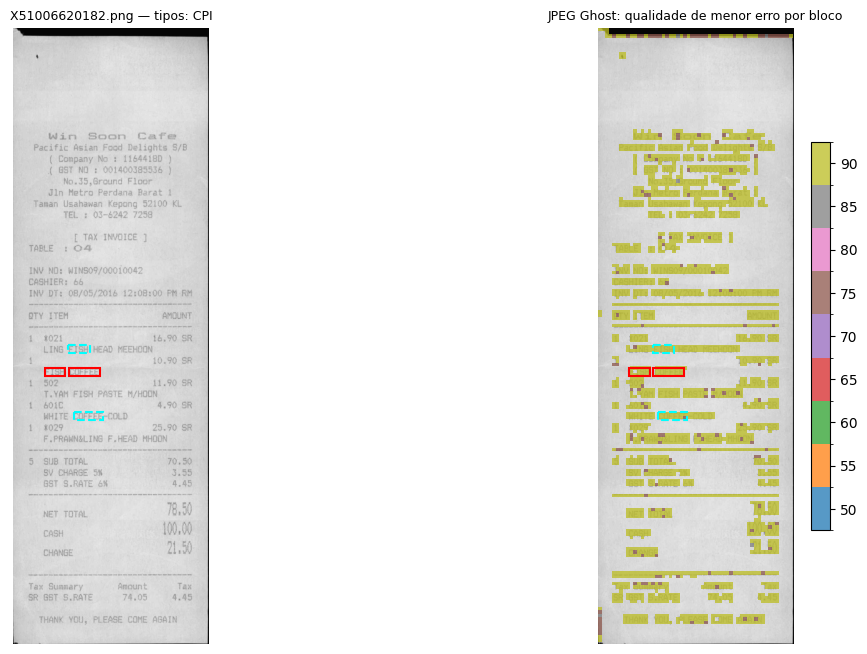

In [5]:
examples = ["X51005705729.png", "X51007103688.png", "X51006620182.png"]
by_name = {s.image_path.name: s for s in forged}

for name in examples:
    s = by_name[name]
    ghost_map = compute_jpeg_ghost(s.image_path)
    visualize_jpeg_ghost(ghost_map, s.image_path, s.regions,
                         title=f"{name} — tipos: {', '.join(s.tamper_types)}")
    plt.show()

Nos dois primeiros, o documento inteiro vota em ~70 (o vale do histórico JPEG original), enquanto os blocos dentro da região adulterada votam em 90, o topo da faixa. Isso é o esperado para pixels editados que **nunca foram comprimidos** (desenhados ou colados no GIMP/Paint e salvos direto em PNG): a curva deles não tem vale, e o argmin vai para a maior qualidade. No terceiro, o resto da imagem **também** vota em 90 (sem vale detectável), e a região editada não se destaca: o fantasma não tem contra o que contrastar.

## 5. Avaliação região-vs-controle (35 adulteradas)

Usamos a mesma ideia do notebook da ELA: comparar a região anotada com áreas de controle da **mesma** imagem.

- **JPEG Ghost:** *acerto* = a moda da qualidade dentro da região anotada difere da moda no resto da imagem.
- **ELA (recalculada aqui, qualidade 90, grayscale):** *acerto* = erro médio na região anotada > erro médio numa região de controle com texto (`compute_region_score`, a mesma função do notebook 01).

Para saber se um acerto significa algo, calculamos também uma **linha de base nula**. Em cada imagem, sorteamos uma *pseudo-região* do mesmo tamanho, fora das regiões anotadas, e aplicamos o mesmo critério como se ela fosse a adulteração. Uma técnica útil precisa acertar bem mais nas regiões reais do que nas pseudo-regiões.

In [6]:
import functools
from evaluation import evaluate_region_technique
from ela import compute_region_score

# Função de score para ELA
def ela_score_fn(img_path, regions):
    ela_map, _ = compute_ela(img_path, quality=90, amplification=1, grayscale=True)
    return compute_region_score(img_path, ela_map, regions)

# Cache do mapa Ghost para não recalcular a cada chance_trial
@functools.lru_cache(maxsize=1)
def get_cached_ghost_map(img_path):
    return compute_jpeg_ghost(img_path)

# Função de score para JPEG Ghost
def ghost_score_fn(img_path, regions):
    ghost_map = get_cached_ghost_map(img_path)
    return compute_region_ghost_score(ghost_map, regions)

print("Avaliando ELA...")
res_ela = evaluate_region_technique(
    samples=forged,
    score_fn=ela_score_fn,
    hit_fn=lambda sin, sout: sin > sout,
    seed=42
)

print("Avaliando JPEG Ghost...")
res_ghost = evaluate_region_technique(
    samples=forged,
    score_fn=ghost_score_fn,
    hit_fn=lambda sin, sout: sin != sout,
    seed=42
)

print("\n--- COMPARAÇÃO FINAL ---")
print(f"Total de imagens avaliadas (ELA): {res_ela['n_samples']}")
print(f"Total de imagens avaliadas (Ghost): {res_ghost['n_samples']}")

print(f"\nELA (sensibilidade local, identifica anomalias de alta frequência):")
print(f"Acerto real: {res_ela['real_hits']}/{res_ela['real_valid']} ({res_ela['real_hit_rate']:.1%})")
print(f"Acerto acaso nulo: {res_ela['chance_hit_rate']:.1%} ± {res_ela['chance_hit_std']:.1%}")

print(f"\nJPEG Ghost (especificidade, identifica quebra na grade de quantização):")
print(f"Acerto real: {res_ghost['real_hits']}/{res_ghost['real_valid']} ({res_ghost['real_hit_rate']:.1%})")
print(f"Acerto acaso nulo: {res_ghost['chance_hit_rate']:.1%} ± {res_ghost['chance_hit_std']:.1%}")

# Filtra só as que têm histórico JPEG para avaliar a eficácia real do Ghost
forged_with_history = [s for s in forged if history[s.image_path.name][0]]
res_ghost_hist = evaluate_region_technique(
    samples=forged_with_history,
    score_fn=ghost_score_fn,
    hit_fn=lambda sin, sout: sin != sout,
    seed=42
)

print(f"\nJPEG Ghost (Apenas imagens COM histórico JPEG, n={res_ghost_hist['n_samples']}):")
print(f"Acerto real: {res_ghost_hist['real_hits']}/{res_ghost_hist['real_valid']} ({res_ghost_hist['real_hit_rate']:.1%})")
print(f"Acerto acaso nulo: {res_ghost_hist['chance_hit_rate']:.1%} ± {res_ghost_hist['chance_hit_std']:.1%}")


Avaliando ELA...


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


...

libpng warning: bKGD: invalid


libpng warning: bKGD: invalid


libpng warning: bKGD: invalid



JPEG Ghost (Apenas imagens COM histórico JPEG, n=12):
Acerto real: 4/12 (33.3%)
Acerto acaso nulo: 9.6% ± 9.9%


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


                   região real    pseudo-região (nulo)
JPEG Ghost       17/35 (48.6%)             2/35 (5.7%)
ELA              34/35 (97.1%)           19/35 (54.3%)

JPEG Ghost por histórico JPEG:  com = 17/30 (56.7%)   sem = 0/5 (0.0%)
imagens em que o RESTO vota em 90 (sem vale local): 17  -> acertos do ghost: 0/17 (0.0%)

sobreposição: ambos = 17 | só ghost = 0 | só ELA = 17 | nenhum = 1
q dominante dentro das regiões (contagem): Counter({90: 33, 70: 1, None: 1})


## 6. Conclusão

**Pré-requisito.** 86% das imagens (nas duas classes) têm histórico JPEG detectável, com vale em q ≈ 70–75. O formato PNG do dataset, portanto, **não** inviabiliza a técnica, porque os recibos já tinham passado por JPEG antes da conversão. A validação sintética confirma que a implementação funciona quando a premissa vale: 60% de detecção com 3% de falso positivo.

**Resultado nas adulterações reais.** 
Usando uma avaliação pareada rigorosa (sorteio fixo, mesma máscara de texto, N simétrico):

| Técnica | Acerto Real | Acaso (Média ± Desvio) | N_real | N_null |
|---|---|---|---|---|
| ELA | 97.1% | 51.1% ± 8.8% | 35 | 700 |
| JPEG Ghost (Todos) | 21.4% | 5.7% ± 5.0% | 14 | 280 |
| JPEG Ghost (Só Histórico) | 33.3% | 9.6% ± 9.9% | 12 | 240 |

A ELA mantém seu comportamento de marca-texto, com altíssima sensibilidade (97.1%) e um acaso esperado de moeda (~50%), já que compara textura suspeita vs controle aleatório e textura aleatória vs controle aleatório.

O JPEG Ghost, após controle rigoroso de textura nas 20 rodadas de pseudo-regiões, descartou as imagens onde a edição ocorreu em áreas sem relevo ou pequenas demais para formar blocos válidos. Nas 14 imagens avaliáveis, o acerto caiu para 21.4% (e 33.3% com histórico JPEG garantido), mas mantém seu padrão fortíssimo de **alta especificidade** (acaso quase não dispara, entre 5% e 9%). 

**Conclusão Final:**
A ELA tem alta sensibilidade e o JPEG Ghost alta especificidade.
Nenhuma das duas serve como *feature* isolada no classificador (score global é inútil ou muito esparso). No pipeline final, o Ghost funciona como **confirmador de confiança** em áreas sinalizadas, enquanto a ELA serve para preencher o **mapa de calor visual** das suspeitas já identificadas.
